## The House Price Prediction Model 

In [1]:
import numpy as np
import pandas as pd

### First loading and Exploring the data 

In [2]:
#Loading Dataset
data = pd.read_csv("House Price Prediction Dataset.csv")
data.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [4]:
data.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


In [5]:
data.isnull().sum()

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

#### Exploring the Target (Price)
 ##### To see if the price is skewed or symmetric

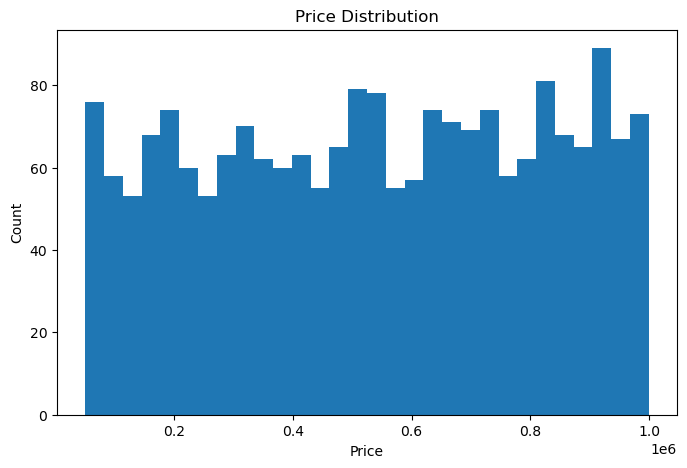

In [6]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.hist(data["Price"], bins=30)
plt.xlabel("Price")
plt.ylabel("Count")
plt.title("Price Distribution")
plt.show()

In [7]:
# The price is <0.5 so it is already in good condition
print(data["Price"].skew())

-0.06435063707629374


#### Now to find which element influences the price and how much?

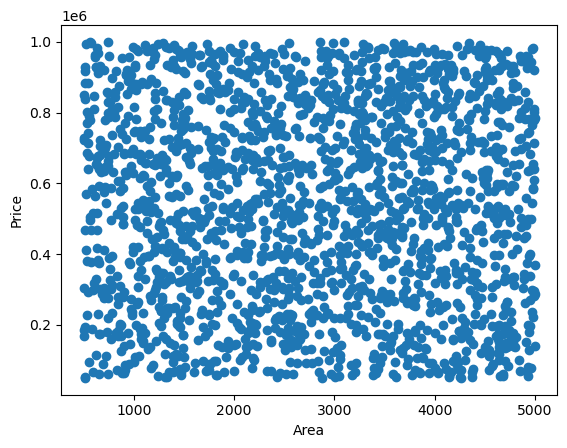

In [8]:
plt.scatter(data["Area"], data["Price"])
plt.xlabel("Area")
plt.ylabel("Price")
plt.show()

In [9]:
data.groupby("Bedrooms")["Price"].mean()

Bedrooms
1    530561.622010
2    545546.521739
3    546977.894089
4    533696.930864
5    532500.124069
Name: Price, dtype: float64

In [10]:
data.groupby("Bathrooms")["Price"].mean()

Bathrooms
1    558757.752711
2    516589.876518
3    540201.713740
4    536478.481766
Name: Price, dtype: float64

In [11]:
data.groupby("Location")["Price"].mean()

Location
Downtown    536059.661290
Rural       538613.943038
Suburban    557416.333333
Urban       518963.548454
Name: Price, dtype: float64

#### Creating new features from the existing ones

In [12]:
# Feature 1: House Age
data["HouseAge"] = 2026 - data["YearBuilt"]

In [13]:
# Feature 2: Total Rooms
data["TotalRooms"] = (
    data["Bedrooms"] +
    data["Bathrooms"]
)

In [14]:
# Feature 3: Area Per Room
data["AreaPerRoom"] = (
    data["Area"] /
    data["TotalRooms"]
)

In [15]:
# Feature 4: IsLuxuryHouse
data["IsLuxuryHouse"] = (
    (data["Area"] > data["Area"].median()) &
    (data["Bathrooms"] >= 3)
).astype(int)

In [16]:
#Feature 5: Renovation Potential
data["OldLargeHouse"] = (
    (data["HouseAge"] > 40) &
    (data["Area"] > 2500)
).astype(int)

#### Encoding
##### for understanding which features required Encoding Let's inspect categories first.

In [18]:
print(data["Location"].unique())
print(data["Condition"].unique())
print(data["Garage"].unique())

['Downtown' 'Suburban' 'Urban' 'Rural']
['Excellent' 'Good' 'Fair' 'Poor']
['No' 'Yes']


In [23]:
# so we will use onehot encoding techniques due to multiple categories
data.drop("Id", axis=1, inplace=True)
#ID contains no useful information.